In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import warnings
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Cases/Concrete_Strength/")

In [9]:
concrete = pd.read_csv("Concrete_Data.csv")
concrete

,Cement,Blast,Fly,Water,Superplasticizer,Coarse,Fine,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [10]:
X, y = concrete.drop("Strength", axis = 1), concrete["Strength"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 26, test_size = 0.3)

In [11]:
# ss = StandardScaler()
# X_train = ss.fit_transform(X_train)
# X_test = ss.transform(X_test)

In [12]:
warnings.filterwarnings('ignore')
lr = LinearRegression()
knn = KNeighborsRegressor()
dtr = DecisionTreeRegressor(random_state = 26)
el = ElasticNet()
estimators = [lr, el, knn, dtr]
no_of_samples = [10,15,50,100]
scores = []
for e in tqdm(estimators):
    for n in no_of_samples:
        bagg = BaggingRegressor(random_state=26, estimator = e, n_estimators=n,n_jobs=-1)
        
        bagg.fit(X_train, y_train)
        y_pred = bagg.predict(X_test)
        scores.append([e,n,r2_score(y_test, y_pred)])

df_scores = pd.DataFrame(scores, columns = ['Estimator Name','No. of Samples', 'R2 Score'])
df_scores.sort_values('R2 Score', ascending = False)

100%|█████████████████████████████████████████████| 4/4 [00:07<00:00,  1.87s/it]


,Estimator Name,No. of Samples,R2 Score
15,DecisionTreeRegressor(random_state=26),100,0.898804
14,DecisionTreeRegressor(random_state=26),50,0.897347
12,DecisionTreeRegressor(random_state=26),10,0.894547
13,DecisionTreeRegressor(random_state=26),15,0.894110
11,KNeighborsRegressor(),100,0.683745
10,KNeighborsRegressor(),50,0.680982
8,KNeighborsRegressor(),10,0.678338
9,KNeighborsRegressor(),15,0.675171
4,ElasticNet(),10,0.620164
0,LinearRegression(),10,0.619629


In [13]:
l = len(X.columns)

In [20]:
features = np.arange(2,l+1)
scores = []
for f in tqdm(features):
    for n in [25,50,75,100,125]:
        rf = RandomForestRegressor(max_features=f,n_estimators=n,random_state=26,max_depth=17)
        rf.fit(X_train,y_train)
        y_pred = rf.predict(X_test)
        scores.append([f,n,r2_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=["No. of Features","No. of Estimators","R2 Score"])
df_scores.sort_values("R2 Score",ascending=False)

100%|█████████████████████████████████████████████| 7/7 [00:07<00:00,  1.11s/it]


,No. of Features,No. of Estimators,R2 Score
24,6,125,0.899140
22,6,75,0.898921
23,6,100,0.898860
34,8,125,0.898498
33,8,100,0.898351
19,5,125,0.898224
32,8,75,0.897895
15,5,25,0.897788
14,4,125,0.897692
29,7,125,0.897527


In [22]:
bm = RandomForestRegressor(max_features=6, n_estimators=125, random_state = 26)
bm.fit(X, y)

RandomForestRegressor(max_features=6, n_estimators=125, random_state=26)

In [24]:
df = pd.DataFrame({'features' : X.columns, 'importances' : bm.feature_importances_})
df = df.sort_values('importances')

<BarContainer object of 8 artists>

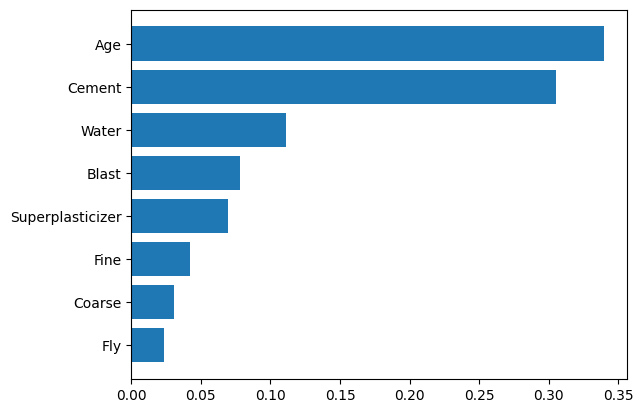

In [26]:
plt.barh(df['features'], df['importances'])